# viz_osm_newbie.ipynb
# visualises newbie changeset locations on map
# input: changeset data for AOI from OSMCha (https://osmcha.org/)
# output: Plot center coordinates of changesets on map


In [2]:
# read data
import os
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta

plt.style.use("seaborn-v0_8")


In [3]:

#1 read changesets data
osmcha_changesets=pd.read_pickle("data/osmcha_changesets.pkl")
osmcha_changesets.head()


,id,type,geometry_type,geometry_coordinates,properties_check_user,properties_reasons,properties_tags,properties_features,properties_user,properties_uid,...,properties_tag_changes_type,properties_tag_changes_name:te,properties_tag_changes_short_name:te,properties_tag_changes_loc_name:name:loc,properties_tag_changes_informal,properties_tag_changes_healthcare,properties_tag_changes_healthcare:speciality,tags_map,first_month,discussion_status
0,176768410,Feature,Polygon,"[[[80.1112946, 16.166866], [80.1112946, 16.166...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 86, ...",[],[],Pavan Komirisetty,23668422,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},2026-01,no_comments
1,176891017,Feature,Polygon,"[[[80.8289802, 16.0351363], [80.8402645, 16.03...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]","[{'id': 10, 'name': 'Unresolved'}]",[],Mohana Dokku,23677212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{10: 'Unresolved'},2026-01,has_comments
2,176892861,Feature,Polygon,"[[[80.1910467, 15.8971858], [80.200224, 15.897...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 517,...","[{'id': 6, 'name': 'Severity: Low'}]",[],Amarnath07,23677287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{6: 'Severity: Low'},2026-01,has_comments
3,176894070,Feature,Polygon,"[[[80.0167603, 15.7050239], [80.0815638, 15.70...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],KrisVar,23677295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},2026-01,has_comments
4,176894166,Feature,Polygon,"[[[79.5521225, 13.6016232], [79.5791831, 13.60...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],Balaraju Bollini,23677297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},2026-01,has_comments


In [4]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

def changeset_centroid(a,b,c,d):
    if (a[0]==b[0] and a[1]==b[1]):
        return(a[0],a[1])
    else:
        return((a[0]+d[0])/2,(a[1]+d[1])/2)

def changeset_point(a,b,c,d):
    if (a[0]==b[0] and a[1]==b[1]):
        return(True)
    else:
        return(False)

# 1. Add geometry directly to the original DataFrame
osmcha_changesets["changeset_centroid"] = osmcha_changesets["geometry_coordinates"].apply(
    lambda x: Point(changeset_centroid(x[0][0], x[0][1], x[0][2], x[0][3]))
)
# 1. Add geometry directly to the original DataFrame
osmcha_changesets["changeset_point"] = osmcha_changesets["geometry_coordinates"].apply(
    lambda x: changeset_point(x[0][0], x[0][1], x[0][2], x[0][3])
)

# 2. Convert to GeoDataFrame safely
osmcha_gdf = gpd.GeoDataFrame(osmcha_changesets, geometry="changeset_centroid", crs="EPSG:4326")


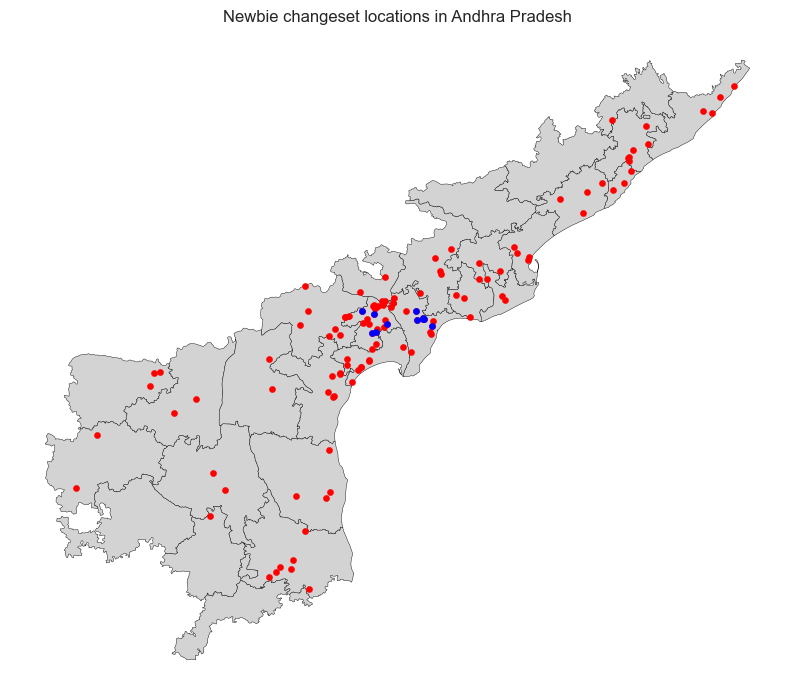

In [5]:
# Load your local GeoJSON file
ap_districts = gpd.read_file("data/ap districts 2026 simplified.geojson")

# 2. Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the base map first
ap_districts.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the points on top

osmcha_gdf.plot(ax=ax, color='red', markersize=20, marker='o')
hotosm_gdf=osmcha_gdf[osmcha_gdf['properties_comment'].str.contains('#hotosm-project-17520')]
hotosm_gdf.plot(ax=ax, color='blue', markersize=20, marker='o')
# Customize and show
plt.title("Newbie changeset locations in Andhra Pradesh")
plt.axis('off')
plt.show()


In [6]:
ap_districts.head()

,fid,id,admin_level,name,name:te,official_name,official_name:te,wikidata,geometry
0,1,relation/2022096,5,Srikakulam,శ్రీకాకుళం,Srikakulam District,శ్రీకాకుళం జిల్లా,Q15395,"POLYGON ((83.77319 18.56627, 83.77779 18.56368..."
1,2,relation/2022097,5,Vizianagaram,విజయనగరం,Vizianagaram District,విజయనగరం జిల్లా,Q15392,"POLYGON ((83.153 18.34023, 83.14951 18.32935, ..."
2,3,relation/2022111,5,Visakhapatnam,విశాఖపట్నం,Visakhapatnam District,విశాఖపట్నం జిల్లా,Q15394,"MULTIPOLYGON (((83.24019 17.61963, 83.24055 17..."
3,4,relation/2022126,5,East Godavari,తూర్పు గోదావరి,East Godavari District,తూర్పు గోదావరి జిల్లా,Q15338,"POLYGON ((81.80392 16.695, 81.79766 16.71423, ..."
4,5,relation/2022127,5,West Godavari,పశ్చిమ గోదావరి,West Godavari District,పశ్చిమ గోదావరి జిల్లా,Q15404,"POLYGON ((81.46 16.89902, 81.46023 16.87991, 8..."


In [7]:

# 2. Print the entire first row as a Series (Column Name -> Value)



for col, val in osmcha_changesets.iloc[0].items():
    print(f"{col}: {val}")


id: 176768410
type: Feature
geometry_type: Polygon
geometry_coordinates: [[[80.1112946, 16.166866], [80.1112946, 16.166866], [80.1112946, 16.166866], [80.1112946, 16.166866], [80.1112946, 16.166866]]]
properties_check_user: arjunaraoc
properties_reasons: [{'id': 40, 'name': 'New mapper'}, {'id': 86, 'name': 'Review requested'}]
properties_tags: []
properties_features: []
properties_user: Pavan Komirisetty
properties_uid: 23668422
properties_editor: iD 2.37.3
properties_comment: The village name was spelled incorrect
properties_comments_count: 0
properties_source: local knowledge
properties_imagery_used: Bing Maps Aerial
properties_date: 2026-01-03 03:35:39+00:00
properties_reviewed_features: []
properties_tag_changes_name: ['Ganganapalem', 'Gangannapalem']
properties_tag_changes_place: ['village']
properties_tag_changes_population: ['1800+']
properties_create: 0
properties_modify: 1
properties_delete: 0
properties_area: 0.0
properties_is_suspect: True
properties_harmful: False
properti

In [8]:
import statistics
print(statistics.median(osmcha_changesets["properties_create"]))
print(statistics.median(osmcha_changesets["properties_modify"]))
print(statistics.median(osmcha_changesets["properties_delete"]))

5.5
1.0
0.0


In [9]:
osmcha_changesets["properties_comment"]

0                 The village name was spelled incorrect
1       Created a residential road near peteru main road
2      Provided connectivity for residential highways...
3      Generated and connected roads near Sri Chennak...
4                          Created roads near Indian Oil
                             ...                        
117                                               Update
118                              Updated the Coffee shop
119                                                  tea
120                                            Completed
121    Sundareswara Ayyappa Swamy Temple, Nelakondapalli
Name: properties_comment, Length: 122, dtype: object

Accurate Counts: {'created': 35, 'road': 26, 'added': 21, 'near': 14, 'hotosmproject17520': 11, 'osmindia': 11, 'andhramapping24': 11, 'updated': 11, 'residential': 8, 'highways': 8}


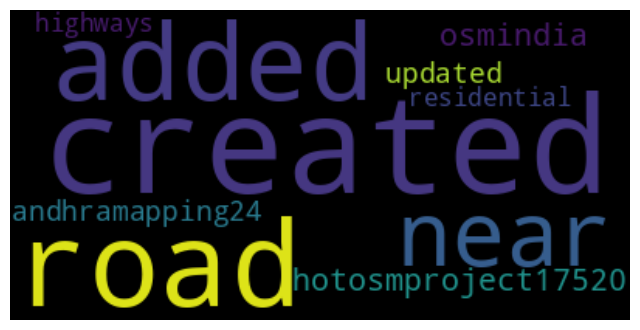

In [10]:
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS, WordCloud

text = osmcha_changesets['properties_comment'].astype(str).str.cat(sep='\n')

# 1. Clean punctuation and lowercase the text
clean_text = re.sub(r"[^\w\s]", "", text.lower())
all_words = clean_text.split()

# 2. Filter out stopwords using a list comprehension
# (STOPWORDS is a fast-lookup set from the wordcloud library)
filtered_words = [word for word in all_words if word not in STOPWORDS]

# 3. Get the top 10 most common filtered words
top_10_counts = dict(Counter(filtered_words).most_common(10))
print("Accurate Counts:", top_10_counts)

# 4. Generate and display the WordCloud
wc = WordCloud().generate_from_frequencies(top_10_counts)

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


In [11]:

# Convert to DataFrame
df = pd.DataFrame(top_10_counts.items(), columns=['Word', 'Count'])
df.to_csv("data/top_10_words.csv", index=False)

In [12]:
# nummber of changesets that are points (i.e., where the coordinates are the same)
osmcha_changesets["changeset_point"].sum()

np.int64(13)

In [13]:
# map the changesets centre to district
# 
# 2. Perform the spatial join
# By passing how='left', you ensure all points are kept, even if they don't fall in any polygon
joined_gdf = gpd.sjoin(osmcha_gdf, ap_districts, how="left", predicate="within")

# 3. Extract the original polygon index
# When joining, the polygon's index is stored in the column 'index_right'
joined_gdf['polygon_index'] = joined_gdf['index_right'].astype('Int64')  # Use Int64 to allow for NaN values
joined_gdf.head()


,id_left,type,geometry_type,geometry_coordinates,properties_check_user,properties_reasons,properties_tags,properties_features,properties_user,properties_uid,...,index_right,fid,id_right,admin_level,name,name:te,official_name,official_name:te,wikidata,polygon_index
0,176768410,Feature,Polygon,"[[[80.1112946, 16.166866], [80.1112946, 16.166...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 86, ...",[],[],Pavan Komirisetty,23668422,...,25.0,26.0,relation/14000417,5,Palnadu,పల్నాడు,Palnadu District,పల్నాడు జిల్లా,Q110714862,25
1,176891017,Feature,Polygon,"[[[80.8289802, 16.0351363], [80.8402645, 16.03...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]","[{'id': 10, 'name': 'Unresolved'}]",[],Mohana Dokku,23677212,...,16.0,17.0,relation/13998258,5,Bapatla,బాపట్ల,Bapatla District,బాపట్ల జిల్లా,Q110876712,16
2,176892861,Feature,Polygon,"[[[80.1910467, 15.8971858], [80.200224, 15.897...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 517,...","[{'id': 6, 'name': 'Severity: Low'}]",[],Amarnath07,23677287,...,16.0,17.0,relation/13998258,5,Bapatla,బాపట్ల,Bapatla District,బాపట్ల జిల్లా,Q110876712,16
3,176894070,Feature,Polygon,"[[[80.0167603, 15.7050239], [80.0815638, 15.70...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],KrisVar,23677295,...,8.0,9.0,relation/2022278,5,Prakasam,ప్రకాశం,Prakasam District,ప్రకాశం జిల్లా,Q15390,8
4,176894166,Feature,Polygon,"[[[79.5521225, 13.6016232], [79.5791831, 13.60...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],Balaraju Bollini,23677297,...,13.0,14.0,relation/13997802,5,Tirupati,తిరుపతి,Tirupati District,తిరుపతి జిల్లా,Q110714853,13


In [14]:
# Create csv file for number of changesets per district
joined_gdf['name'].value_counts().to_csv("data/changesets_per_district.csv", index=True, header=True)

In [15]:
# list of districts that have no changesets
missing_indices = ap_districts.index[~ap_districts.index.isin(joined_gdf['polygon_index'].dropna())]
missing_gpd=ap_districts.iloc[missing_indices]
missing_gpd=missing_gpd.dropna(subset=['admin_level'])
missing_gpd['name']

12                 Chittoor
15           Sri Sathya Sai
19    Alluri Sitharama Raju
26                Polavaram
Name: name, dtype: object

In [16]:
# map the changesets centre to district
# 
# 2. Perform the spatial join
# By passing how='left', you ensure all points are kept, even if they don't fall in any polygon
hotosm_joined_gdf = gpd.sjoin(hotosm_gdf, ap_districts, how="left", predicate="within")

# 3. Extract the original polygon index
# When joining, the polygon's index is stored in the column 'index_right'
hotosm_joined_gdf['polygon_index'] = hotosm_joined_gdf['index_right'].astype('Int64')  # Use Int64 to allow for NaN values


hotosm_joined_gdf['name'].value_counts()

name
Krishna    6
Guntur     5
Name: count, dtype: int64

In [17]:
osmcha_changesets['properties_reasons'].to_csv("data/reason_comments.csv", index=True, header=True)